### PCA on MNIST Data Set 

this tutorial would use keras. 

refr : https://bsc-iitm.github.io/MLT_notes/pages/Not01.html#reconstruction-using-the-two-pcs

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
from keras.datasets import mnist

In [5]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X = X_train[y_train == 2][: 100].reshape(-1, 28 * 28).T
test_image = X_test[y_test == 2][0].reshape(28 * 28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


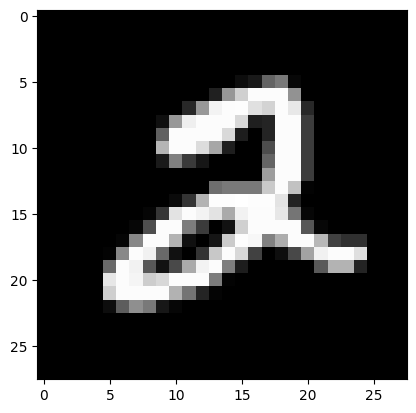

In [6]:
img = X[:,0].reshape(28, 28)
plt.imshow(img, cmap = 'gray')

### 1. Center the data set about the mean

In [7]:
def center(x): 
    return x - x.mean(axis=1).reshape(-1, 1)

X_prime = center(X)

### 2. Compute the Covariance Matrix

In [8]:
def covr(X): 
    n = X.shape[1]
    return (X @ X.T)/n

C = covr(X_prime)

### 3. Compute the 1<sup>st</sup> and 2<sup>nd</sup> Eigenvectors

In [9]:
def compute_pc(C): 
    eigval , eigvec = np.linalg.eigh(C)
    w1, w2 = eigvec[:,-1], eigvec[:,-2]
    return w1, w2

w1 , w2 = compute_pc(C)

have a look at the eigenvectors 

Text(0.5, 1.0, '2nd eigen vector')

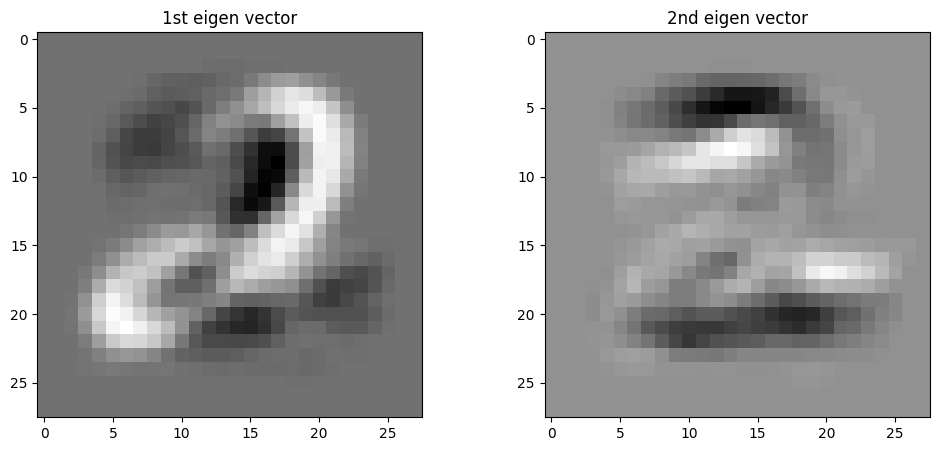

In [12]:
w1_img = w1.reshape(28,28)
w2_img = w2.reshape(28, 28)

plt.figure(figsize=(12, 5))
plt.subplot(1 , 2 ,1)
plt.imshow(w1_img, cmap="gray")
plt.title("1st eigen vector")

plt.subplot(1 , 2 , 2)
plt.imshow(w2_img , cmap="gray")
plt.title("2nd eigen vector")

<b>what next : </b><br>

<p>Given a {test_image}, visualize the proxies by reconstructing it using the top k principal components. Consider four values of k</p>
<p>for which the top-principal components explain:</p>

<ul>
    <li>20% of the variance</li>
    <li>50% of the variance</li>
    <li>80% of the variance</li>
    <li>95% of the variance</li>
</ul>


Text(0.5, 1.0, '100% variance covered')

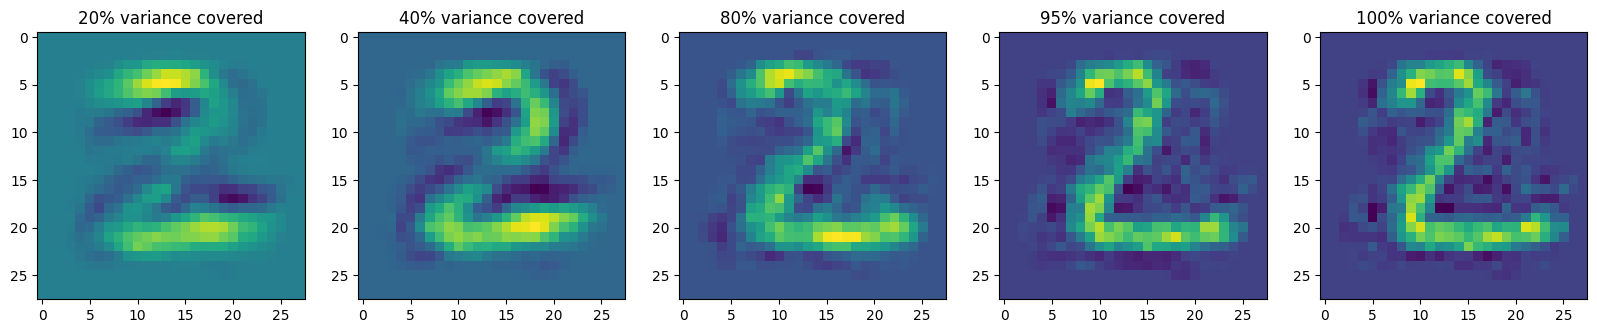

In [22]:
def reconstruct(C, test_image , thresh): 
    eigval ,eigvec = np.linalg.eigh(C)
    eigval = list(reversed(eigval))
    
    tot = sum(eigval)
    K = len(eigval)
    
    for i in range(len(eigval)):
        if sum(eigval[ : i+1])/tot >= thresh: 
            K = i + 1 
            break 
    
    W = eigvec[:, -K:]
    coeffs = test_image @ W 
    return W @ coeffs

# PLOTTING BUSINESS 
plt.figure(figsize=(20, 20))

plt.subplot(1 , 5 ,1)
rec1_img = reconstruct(C, test_image, 0.2).reshape(28, 28)
plt.imshow(rec1_img)
plt.title("20% variance covered")

plt.subplot(1 , 5 , 2)
rec2_img = reconstruct(C, test_image, 0.4).reshape(28, 28)
plt.imshow(rec2_img)
plt.title("40% variance covered")

plt.subplot(1 , 5 , 3)
rec3_img = reconstruct(C, test_image, 0.8).reshape(28 , 28)
plt.imshow(rec3_img)
plt.title("80% variance covered")

plt.subplot(1 , 5 , 4)
rec4_img = reconstruct(C, test_image, 0.95).reshape(28, 28)
plt.imshow(rec4_img)
plt.title("95% variance covered")

plt.subplot(1 , 5 , 5)
rec5_img = reconstruct(C, test_image, 1.0).reshape(28 , 28)
plt.imshow(rec5_img)
plt.title("100% variance covered")

Text(0.5, 1.0, 'Mean subtracted test_image')

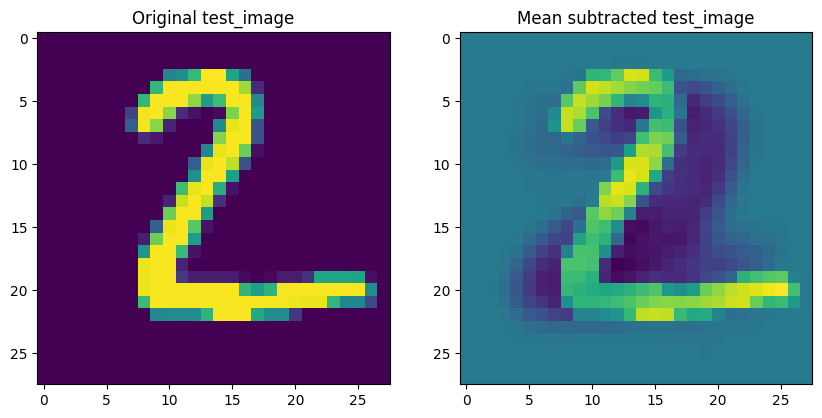

In [27]:
# plotting the original and the mean subtracted original 
plt.figure(figsize=(10, 10))
plt.subplot(1 , 2  , 1)
plt.imshow(test_image.reshape(28,28))
plt.title("Original test_image")

test_image_mean_sub = np.float64(test_image) - X.mean(axis = 1)

plt.subplot(1 , 2  , 2)
plt.imshow(test_image_mean_sub.reshape(28,28))
plt.title("Mean subtracted test_image")